<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/TT_amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/amazon_reviews_small.csv')
pd.set_option('display.max_columns', None)

In [ ]:
df.shape

(24308, 25)

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24308 entries, 0 to 24307
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0.2                          24308 non-null  int64  
 1   level_0                               24308 non-null  int64  
 2   Unnamed: 0.1                          24308 non-null  int64  
 3   index                                 24308 non-null  int64  
 4   Unnamed: 0                            24308 non-null  int64  
 5   ASIN                                  24308 non-null  object 
 6   Review_Title                          24303 non-null  object 
 7   Review_Content                        24308 non-null  object 
 8   Review_Stars                          24308 non-null  float64
 9   Review_Date                           24308 non-null  object 
 10  Reviewer_Name                         23059 non-null  object 
 11  Verified_Purcha

In [ ]:
# for c in df.select_dtypes('object'):
#  df[c] = df[c].astype('object')

In [ ]:
for i in df.select_dtypes('integer'):
  df[i] = pd.to_numeric(df[i], downcast='integer')

In [ ]:
for f in df.select_dtypes('float'):
  df[f] = pd.to_numeric(df[f], downcast='float')

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24308 entries, 0 to 24307
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0.2                          24308 non-null  int16  
 1   level_0                               24308 non-null  int32  
 2   Unnamed: 0.1                          24308 non-null  int32  
 3   index                                 24308 non-null  int32  
 4   Unnamed: 0                            24308 non-null  int32  
 5   ASIN                                  24308 non-null  object 
 6   Review_Title                          24303 non-null  object 
 7   Review_Content                        24308 non-null  object 
 8   Review_Stars                          24308 non-null  float32
 9   Review_Date                           24308 non-null  object 
 10  Reviewer_Name                         23059 non-null  object 
 11  Verified_Purcha

In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

In [ ]:
nulls_count = df.isnull().sum()
nulls_count[nulls_count > 0].sort_values(ascending=False)

,0


In [ ]:
nulls_percentage = df.isnull().mean()*100
nulls_percentage[nulls_percentage > 0].sort_values(ascending=False)

,0


In [ ]:
duplicates_sum = df.duplicated().sum()
duplicates_sum

np.int64(0)

In [ ]:
duplicates_percentage = (df.duplicated().sum()/df.shape[0]) * 100
duplicates_percentage

np.float64(0.0)

In [ ]:
# show_duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head()
# show_duplicates

In [ ]:
# df = df.drop_duplicates()

In [ ]:
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1


In [ ]:
df.fillna({'review_title': 'no review'}, inplace=True)

In [ ]:
df.fillna({'verified_purchase': 'unverified purchase'}, inplace=True)

In [ ]:
df.fillna({'rating': 'no rating'}, inplace=True)

In [ ]:
df.fillna({'product_description': 'no description'}, inplace=True)

In [ ]:
unknown_cols = ['brand', 'product_name', 'reviewer_name']
df[unknown_cols] = df[unknown_cols].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24308 entries, 0 to 24307
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   unnamed:_0.2                          24308 non-null  int16  
 1   level_0                               24308 non-null  int32  
 2   unnamed:_0.1                          24308 non-null  int32  
 3   index                                 24308 non-null  int32  
 4   unnamed:_0                            24308 non-null  int32  
 5   asin                                  24308 non-null  object 
 6   review_title                          24308 non-null  object 
 7   review_content                        24308 non-null  object 
 8   review_stars                          24308 non-null  float32
 9   review_date                           24308 non-null  object 
 10  reviewer_name                         24308 non-null  object 
 11  verified_purcha

**¿Cual ha sido la review mas util?**

In [ ]:
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1


In [ ]:
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

In [ ]:
df['helpful_votes'].dtype

dtype('int16')

In [ ]:
max_helpful_votes = df['helpful_votes'].max()
max_helpful_votes

np.int16(921)

In [ ]:
helpful_review = df.loc[df['helpful_votes'] == max_helpful_votes][['index', 'review_title', 'review_content', 'review_stars', 'review_date', 'reviewer_name', 'verified_purchase', 'helpful_votes', 'product_name', 'brand', 'rating', 'product_description', 'category', 'cleaned_review']]
helpful_review

,index,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,product_name,brand,rating,product_description,category,cleaned_review
6141,24564,Wouldn’t recommend,"Everything is working as it should, Love the p...",1.0,"Reviewed in the United States on January 27, 2022",LMealy,Verified Purchase,921,Unknown,Unknown,no rating,no description,Mobile,everything is working as it should love the phone


In [ ]:
most_help_review = df.loc[df['helpful_votes'].idxmax()][['index', 'review_title', 'review_content', 'review_stars', 'review_date', 'reviewer_name', 'verified_purchase', 'helpful_votes', 'product_name', 'brand', 'rating', 'product_description', 'category', 'cleaned_review']]
most_help_review

,6141
index,24564
review_title,Wouldn’t recommend
review_content,"Everything is working as it should, Love the p..."
review_stars,1.0
review_date,"Reviewed in the United States on January 27, 2022"
reviewer_name,LMealy
verified_purchase,Verified Purchase
helpful_votes,921
product_name,Unknown
brand,Unknown


**Obtener la review mas util para los productos de la categoria laptop.**

In [ ]:
df.columns

Index(['unnamed:_0.2', 'level_0', 'unnamed:_0.1', 'index', 'unnamed:_0',
       'asin', 'review_title', 'review_content', 'review_stars', 'review_date',
       'reviewer_name', 'verified_purchase', 'helpful_votes', 'review_url',
       'product_name', 'brand', 'rating', 'product_description', 'category',
       'cleaned_review_content', 'cleaned_review',
       'predicted_sentiment_distilbert',
       'predicted_sentiment_label_distilbert', 'predicted_sentiment_roberta',
       'predicted_sentiment_label_roberta'],
      dtype='object')

In [ ]:
df['category'].unique()

array(['Mobile', 'Earphones', 'Laptop', 'TV'], dtype=object)

In [ ]:
category_grp = df.groupby('category')

In [ ]:
df_laptops = category_grp.get_group('Laptop')
df_laptops.shape

(1619, 25)

In [ ]:
df_laptops.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
19253,19253,38506,38506,77012,77012,B0947BJ67M,Excellent for price.,Thin and well finished. Typical excellent HP q...,5.0,"Reviewed in the United States on September 16,...",John S. Presnick,Verified Purchase,0,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,thin and well finished typical excellent hp qu...,thin and well finished typical excellent hp qu...,0,Negative,2,1
19254,19254,38508,38508,77016,77016,B0947BJ67M,"Works great, great price",I see posts of negative reviews about yhe good...,5.0,"Reviewed in the United States on August 22, 2024",Unknown,Verified Purchase,5,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,i see posts of negative reviews about yhe good...,i see posts of negative reviews about yhe good...,1,Positive,2,1
19255,19255,38510,38510,77020,77020,B0947BJ67M,"HP 14 Laptop: Great for a notebook under $200,...",The HP 14 is a great choice for those looking ...,4.0,"Reviewed in the United States on July 7, 2024",Brit,Verified Purchase,0,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,the hp is a great choice for those looking for...,the hp is a great choice for those looking for...,0,Negative,2,1
19256,19256,38512,38512,77024,77024,B0947BJ67M,Works fine,I use it for internet to study and watch lectu...,5.0,"Reviewed in the United States on September 4, ...",Allan R,Verified Purchase,2,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,i use it for internet to study and watch lectu...,i use it for internet to study and watch lectu...,0,Negative,2,1
19257,19257,38514,38514,77028,77028,B0947BJ67M,Go 14,Works slow but good enough to access all my ac...,4.0,"Reviewed in the United States on July 20, 2024",Jenny Avril,Verified Purchase,15,https://www.amazon.com/product-reviews/B0947BJ...,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",Visit the HP Store,4.5 out of 5 stars,About this itemREADY FOR ANYWHERE – With its t...,Laptop,works slow but good enough to access all my ac...,works slow but good enough to access all my ac...,1,Positive,2,1


In [ ]:
laptop_helpful_review = df_laptops.loc[df_laptops['helpful_votes'].idxmax()]
laptop_helpful_review[['review_title', 'review_content', 'review_stars', 'reviewer_name', 'verified_purchase', 'helpful_votes', 'product_name', 'brand', 'rating', 'product_description', 'cleaned_review']]

,19669
review_title,Soooo gooddd!!
review_content,"It's good, useful, fast."
review_stars,5.0
reviewer_name,krozz96
verified_purchase,Verified Purchase
helpful_votes,649
product_name,"HP Newest 14"" HD Laptop, Windows 11, Intel Cel..."
brand,Visit the Amazon Renewed Store
rating,4.5 out of 5 stars
product_description,About this item14” Diagonal HD BrightView WLED...


**¿Cual es la review mas comun?**

In [ ]:
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1


In [ ]:
df['review_stars'].value_counts(normalize=True)

,proportion
review_stars,
5.0,0.525095
4.0,0.209437
1.0,0.113008
3.0,0.097787
2.0,0.054673


In [ ]:
df['rating'].value_counts(normalize=True).head()

,proportion
rating,
no rating,0.388062
4.3 out of 5 stars,0.119878
4.2 out of 5 stars,0.106673
4.4 out of 5 stars,0.090176
4.0 out of 5 stars,0.068907


**¿Que porcentaje de reviews son positivas y negativas?**

Todas las reviews de 4 y 5 estrellas son consideradas positivas. Las demas son consideradas negativas.

In [ ]:
df_reviews = pd.DataFrame(df['review_stars'].value_counts()).reset_index()
df_reviews['%'] = round((df_reviews['count'] / df_reviews['count'].sum()) * 100, 2)
df_reviews

,review_stars,count,%
0,5.0,12764,52.51
1,4.0,5091,20.94
2,1.0,2747,11.30
3,3.0,2377,9.78
4,2.0,1329,5.47


In [ ]:
print(f'Cantidad de Reviews Positivas: {df_reviews.iloc[0]['count'] + df_reviews.iloc[1]['count']}')
print(f'Cantidad de Reviews Negativas: {df_reviews.iloc[2]['count'] + df_reviews.iloc[3]['count'] + df_reviews.iloc[4]['count']}')

Cantidad de Reviews Positivas: 17855.0
Cantidad de Reviews Negativas: 6453.0


In [ ]:
print(f'Porcentaje de Reviews Positivas: {df_reviews.iloc[0]['%'] + df_reviews.iloc[1]['%']} %')
print(f'Porcentaje de Reviews Negativas: {round(df_reviews.iloc[2]['%'] + df_reviews.iloc[3]['%'] + df_reviews.iloc[4]['%'], 2)} %')

Porcentaje de Reviews Positivas: 73.45 %
Porcentaje de Reviews Negativas: 26.55 %


**¿Existe relacion entre la longitud de la review y su cantidad de votos utiles?**

Se crea una nueva columna con la longitud de cada review.

In [ ]:
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1


In [ ]:
df['review_length'] = df['cleaned_review'].str.len()
df.head()

,unnamed:_0.2,level_0,unnamed:_0.1,index,unnamed:_0,asin,review_title,review_content,review_stars,review_date,reviewer_name,verified_purchase,helpful_votes,review_url,product_name,brand,rating,product_description,category,cleaned_review_content,cleaned_review,predicted_sentiment_distilbert,predicted_sentiment_label_distilbert,predicted_sentiment_roberta,predicted_sentiment_label_roberta,review_length
0,0,0,0,0,0,B0CMDJ844V,Super Fast Cell Phone with Great Camera,⭐️⭐️⭐️⭐️⭐️\n\nThe SAMSUNG Galaxy S24 Ultra is ...,5.0,"Reviewed in the United States on August 15, 2024",MZ,Verified Purchase,36,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,the samsung galaxy s ultra is an absolute powe...,the samsung galaxy s ultra is an absolute powe...,1,Positive,2,1,1391
1,1,2,2,4,4,B0CMDJ844V,Big and beautiful,Phone is big and beautiful. OS is super quick....,5.0,"Reviewed in the United States on August 30, 2024",Adrian,Verified Purchase,8,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,phone is big and beautiful os is super quick c...,phone is big and beautiful os is super quick c...,1,Positive,2,1,532
2,2,4,4,8,8,B0CMDJ844V,Refined to a very powerful practical tool,I had the S23 ultra but ran it over by acciden...,4.0,"Reviewed in the United States on September 6, ...",RMI,Verified Purchase,2,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,i had the s ultra but ran it over by accident ...,i had the s ultra but ran it over by accident ...,1,Positive,1,2,1141
3,3,6,6,12,12,B0CMDJ844V,"Bought it ""Used"" got lucky, came with box look...",I've only owned every version of the Note seri...,4.0,"Reviewed in the United States on April 9, 2024",MZ,Verified Purchase,0,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,ive only owned every version of the note serie...,ive only owned every version of the note serie...,0,Negative,1,2,2456
4,4,8,8,16,16,B0CMDJ844V,"Big, beautiful screen and super fast CPU",Samsung Galaxy S24 Ultra 512gb unlocked versio...,5.0,"Reviewed in the United States on August 30, 2024",Alex Beyer,Verified Purchase,5,https://www.amazon.com/product-reviews/B0CMDJ8...,"SAMSUNG Galaxy S24 Ultra Cell Phone, 256GB AI ...",Visit the SAMSUNG Store,4.5 out of 5 stars,About this itemCIRCLE & SEARCH¹ IN A SNAP: Wha...,Mobile,samsung galaxy s ultra gb unlocked version wha...,samsung galaxy s ultra gb unlocked version wha...,1,Positive,2,1,454


In [ ]:
df_votes_review_length = df[['helpful_votes', 'review_length']]
df_votes_review_length.head()

,helpful_votes,review_length
0,36,1391
1,8,532
2,2,1141
3,0,2456
4,5,454


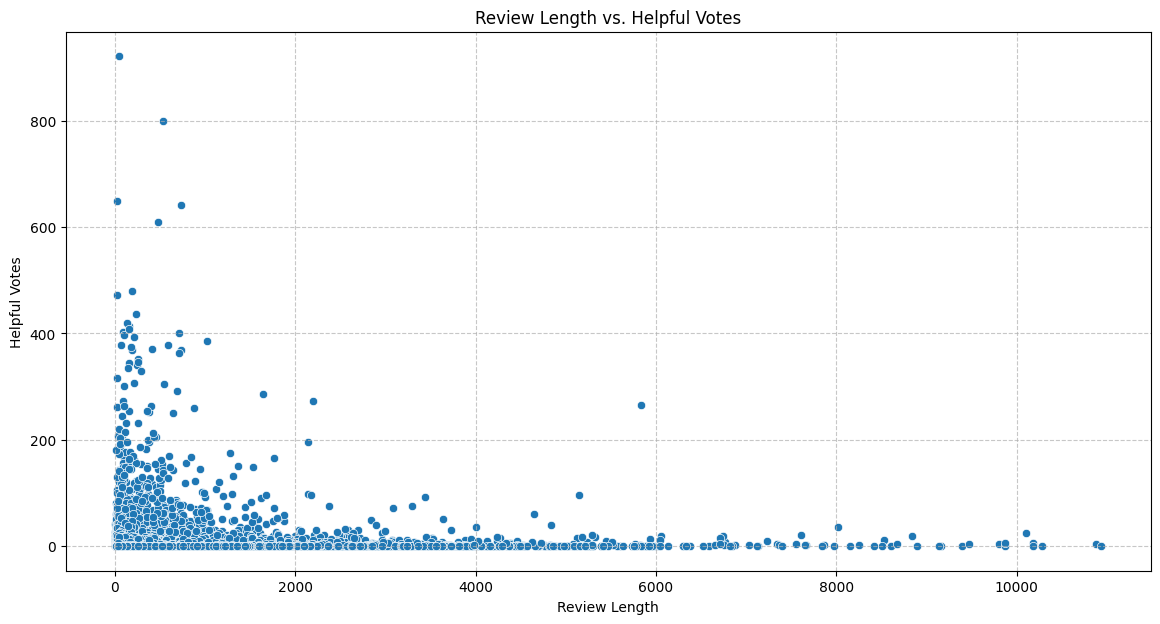

In [ ]:
plt.figure(figsize=(14, 7))
sns.scatterplot(x='review_length', y='helpful_votes', data=df_votes_review_length)
plt.title('Review Length vs. Helpful Votes')
plt.xlabel('Review Length')
plt.ylabel('Helpful Votes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
correlation = df_votes_review_length['review_length'].corr(df_votes_review_length['helpful_votes'])
print(f"Pearson correlation between Review Length and Helpful Votes: {correlation:.2f}")

Pearson correlation between Review Length and Helpful Votes: -0.01
